In [129]:
# Import librării
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV, KFold

1.Explorarea initiala a datelor

In [130]:
#import dataset
house_df=pd.read_csv("house_1.csv")

In [131]:
#afisam primele 5 observatii
house_df.head()

,Unnamed: 0,Address,Zip,Price,Area,Room,Lon,Lat
0,1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
1,2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
2,3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
3,4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
4,5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


In [132]:
print("===== Rezumat DataFrame =====")
house_df.info()

===== Rezumat DataFrame =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  924 non-null    int64  
 1   Address     924 non-null    object 
 2   Zip         924 non-null    object 
 3   Price       920 non-null    float64
 4   Area        924 non-null    int64  
 5   Room        924 non-null    int64  
 6   Lon         924 non-null    float64
 7   Lat         924 non-null    float64
dtypes: float64(3), int64(3), object(2)
memory usage: 57.9+ KB


Setul de date descrie locuințe din Amsterdam și conține opt coloane: adresă, cod poștal, preț, suprafață, număr de camere, longitudine, latitudine și o coloană index. Tipurile de date sunt mixte —int,object,float(textuale, numerice întregi și zecimale). În general, informațiile sunt complete, cu excepția câtorva valori lipsă la preț. Acest set este potrivit pentru analize de piață imobiliară, statistici descriptive sau modele predictive care estimează prețul pe baza dimensiunii, numărului de camere și localizării. Coloana „Unnamed: 0” are rol de index și nu influențează conținutul analitic, putând fi exclusă din prelucrări.De asemenea,voi exclude si Address si Zip inainte de a face matricea de corelatie,intrucat sunt irelevante. Nu avem coloane categoriale.

2. Analiza statistică și verificarea inițială a calității datelor

In [133]:
print("===== Număr de valori unice per coloană =====")
house_df.nunique()

===== Număr de valori unice per coloană =====


Unnamed: 0    924
Address       919
Zip           834
Price         226
Area          193
Room           13
Lon           894
Lat           886
dtype: int64

In [134]:
# Verificarea valorilor lipsă 
missing_values =house_df.isna().sum()
if missing_values.sum() > 0:
    print("Valori lipsă pe coloană:")
    print(missing_values[missing_values > 0])
else:
    print("Nu există valori lipsă în setul de date.")

Valori lipsă pe coloană:
Price    4
dtype: int64


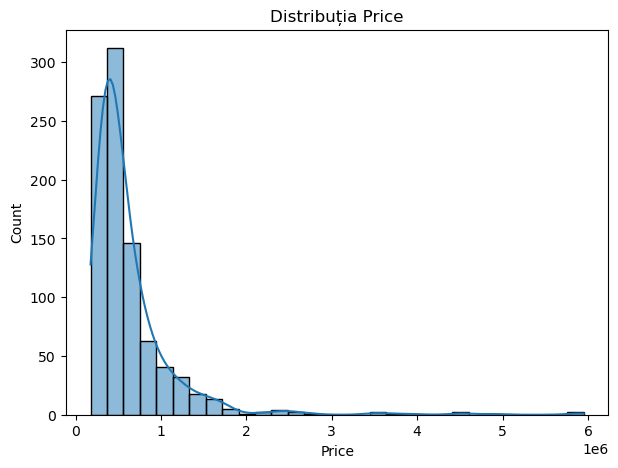

In [135]:
#Histograma
# Setearea dimensiunii figurii pentru grafic
plt.figure(figsize=(7,5))  

# Crearea unei histograme cu curba de densitate (KDE) pentru variabila țintă Price
sns.histplot(house_df['Price'], kde=True, bins=30)  

# Adăugarea titlului pentru grafic
plt.title('Distribuția Price')  

# Afișare grafic
plt.show() 

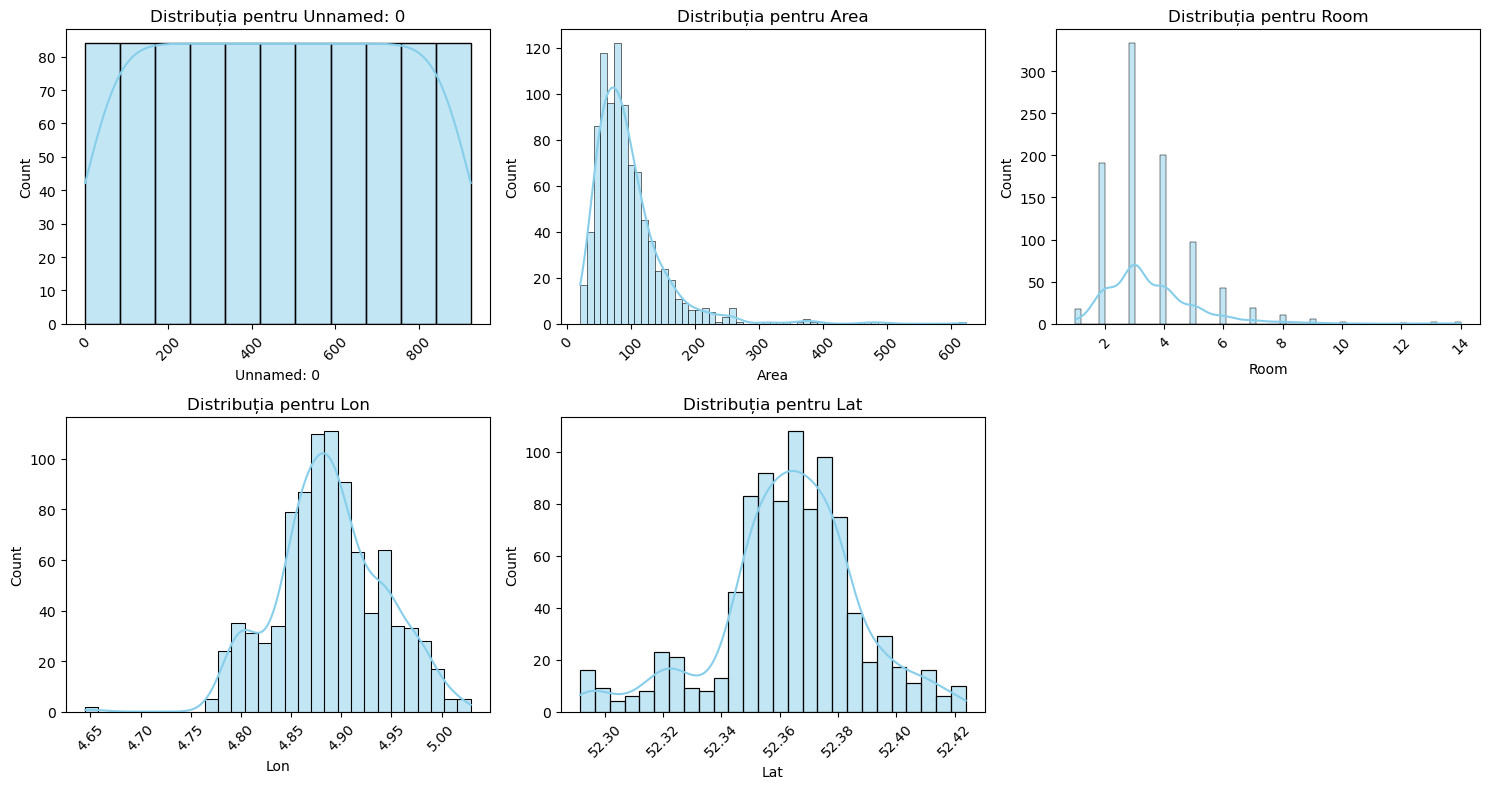

In [136]:
# Distribuția tuturor variabilelor

# Selectarea coloanelor numerice
house_df_plot=house_df.drop('Price', axis=1)
num_cols = house_df_plot.select_dtypes(include=[np.number]).columns

# Setare subgraficului
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows*4))
axes = axes.flatten()

# Creare distplot pentru fiecare coloană numerică
for i, col in enumerate(num_cols):
    sns.histplot(house_df_plot[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f"Distribuția pentru {col}")
    axes[i].tick_params(axis='x', rotation=45)

# Ascunderea subploturilor goale
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

Distribuția Price

Graficul arată că prețurile locuințelor din Amsterdam sunt puternic asimetrice spre dreapta. Majoritatea proprietăților au prețuri mai mici, în jur de câteva sute de mii de euro, în timp ce un număr redus de locuințe sunt foarte scumpe, ajungând la câteva milioane. Această formă sugerează că există diferențe mari între segmentele pieței, iar locuințele de lux acționează ca outlieri, ridicând media generală. În concluzie, distribuția indică o piață dominată de locuințe accesibile, dar cu o mică parte de proprietăți exclusiviste.


Distribuția pentru Unnamed: 0

Această coloană reprezintă doar indexul rândurilor din setul de date, adică numerotarea automată a înregistrărilor. Distribuția este uniformă, ceea ce confirmă că valorile cresc constant și nu conțin informație utilă pentru analiză. În consecință, această variabilă nu influențează rezultatele statistice și poate fi eliminată sau ignorată în etapa de prelucrare a datelor.


Distribuția pentru Area

Suprafața locuințelor are o distribuție asimetrică spre dreapta, similară cu cea a prețurilor. Majoritatea locuințelor au suprafețe mici și medii (sub 100 m²), în timp ce locuințele foarte spațioase sunt mult mai rare. Aceasta reflectă structura tipică a pieței imobiliare din Amsterdam, unde predomină apartamentele compacte. Valorile mari pot reprezenta case individuale sau proprietăți din zone premium.

Distribuția pentru Room

Numărul de camere este o variabilă discretă, iar graficul arată că cele mai multe locuințe au între 2 și 4 camere. Frecvența scade rapid după 5 camere, ceea ce indică faptul că proprietățile foarte mari sunt puține. Distribuția confirmă că locuințele tipice din Amsterdam sunt apartamente sau case mici, potrivite pentru familii reduse ca mărime sau pentru tineri profesioniști.

Distribuția pentru Lon (longitudine)

Distribuția longitudinii este aproape simetrică, având o formă asemănătoare cu o curbă normală. Valorile se grupează în jurul unei zone centrale, ceea ce înseamnă că majoritatea locuințelor se află într-o arie geografică relativ restrânsă. Nu se observă valori extreme, deci toate punctele par să aparțină efectiv regiunii Amsterdamului.

Distribuția pentru Lat (latitudine)

La fel ca în cazul longitudinii, și latitudinea are o distribuție aproape normală, concentrată în jurul unei valori medii. Asta confirmă faptul că datele sunt geografic compacte — locuințele sunt localizate într-un spațiu urban bine definit. Distribuția regulată arată că nu există înregistrări greșite sau proprietăți situate în afara zonei analizate.

3. Curățarea și pregătirea datelor

In [137]:
print("===== Date lipsă ===== ") 
house_df.isna().sum()

===== Date lipsă ===== 


Unnamed: 0    0
Address       0
Zip           0
Price         4
Area          0
Room          0
Lon           0
Lat           0
dtype: int64

In [138]:
# Eliminăm rândurile cu date lipsă
house_df = house_df.dropna()

In [139]:
# Verificăm că s-a efectuat corect eliminarea
print("===== Date curate ===== ") 
house_df.isna().sum()

===== Date curate ===== 


Unnamed: 0    0
Address       0
Zip           0
Price         0
Area          0
Room          0
Lon           0
Lat           0
dtype: int64

In [140]:
# Calcularea Q1, Q3 și IQR pentru MEDV
Q1 = house_df["Price"].quantile(0.25)
Q3 = house_df["Price"].quantile(0.75)
IQR = Q3 - Q1

# Limitele pentru outlieri
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Limita inferioară:", lower_bound)
print("Limita superioară:", upper_bound)

# Eliminarea outlierilor 
house_df_original= house_df
house_df = house_df[(house_df["Price"] >= lower_bound) & (house_df["Price"] <= upper_bound)]
print("Dimensiune dataset original:", house_df_original.shape)
print("Dimensiune dataset fără outlieri:", house_df.shape)

# Verificarea valorilor pentru siguranță
print("Valori maxime Price după eliminare:", house_df["Price"].max())
print("Valori minime Price după eliminare:", house_df["Price"].min())

Limita inferioară: -175000.0
Limita superioară: 1225000.0
Dimensiune dataset original: (920, 8)
Dimensiune dataset fără outlieri: (849, 8)
Valori maxime Price după eliminare: 1200000.0
Valori minime Price după eliminare: 175000.0


In [141]:
#Stergem si coloanele irelevante
house_df = house_df.drop(['Address', 'Zip', 'Unnamed: 0'], axis=1)

In [142]:
# Verificăm că s-a efectuat corect eliminarea
print("===== Date curate ===== ") 
house_df.isna().sum()

===== Date curate ===== 


Price    0
Area     0
Room     0
Lon      0
Lat      0
dtype: int64

În procesul de curățare a datelor, am folosit mai multe tehnici de bază pentru a obține un set de date coerent și fără valori aberante.

În primul rând, am verificat prezența valorilor lipsă folosind metoda isna().sum(). Rezultatul a arătat că doar coloana Price conținea patru valori lipsă. Pentru a evita erori în analizele statistice și în antrenarea modelelor predictive, am ales să elimin rândurile care conțineau valori lipsă prin funcția dropna(). Această metodă este simplă și potrivită deoarece numărul de înregistrări lipsă era foarte mic (doar 4 din 924), deci pierderea de informație este nesemnificativă.

Apoi, am aplicat o tehnică de detectare și eliminare a valorilor extreme (outlieri), folosind metoda IQR (Interquartile Range). Am calculat primul și al treilea cuartil (Q1 și Q3), iar pe baza acestora am determinat limitele inferioare și superioare. Valorile situate în afara intervalului [Q1 - 1.5*IQR, Q3 + 1.5*IQR] au fost considerate anormale și eliminate. Această tehnică ajută la reducerea influenței locuințelor cu prețuri foarte mari, care ar putea distorsiona media și relațiile dintre variabile.

În final, am aplicat o curățare structurală, eliminând coloanele irelevante pentru analiză (Address, Zip, Unnamed: 0). Acestea conțin informații de tip identificator (text sau index) care nu aduc valoare analitică și ar putea doar să încarce inutil setul de date.

Ce date au fost eliminate și care a fost motivația

1.Randuri cu valori lipsa la "Price"

Motivație: lipsa prețului face imposibilă utilizarea acelor observații în analize legate de valoarea locuințelor; eliminarea lor nu afectează semnificativ volumul total de date.

2.Outlieri din coloana "Price"(67 de randuri eliminate)

Motivație: locuințele cu prețuri extreme (peste 1.225.000 €) pot influența negativ media și pot duce la interpretări greșite. După eliminare, setul de date a trecut de la 920 la 849 de înregistrări, menținând doar valorile realiste (între 175.000 € și 1.200.000 €).

3.Coloane irelevante-Adress,Zip,Unnamed

Motivație: aceste coloane sunt de tip text sau index, nefolositoare pentru analiza numerică a prețurilor. Eliminarea lor simplifică structura setului și previne posibile erori la modelare.
Prin aplicarea acestor tehnici, setul de date a fost curățat de valori lipsă, extreme și informații inutile. Rezultatul final este un set curat, coerent și echilibrat, care conține doar variabile numerice relevante (Price, Area, Room, Lon, Lat) și este potrivit pentru analize statistice sau modele predictive.

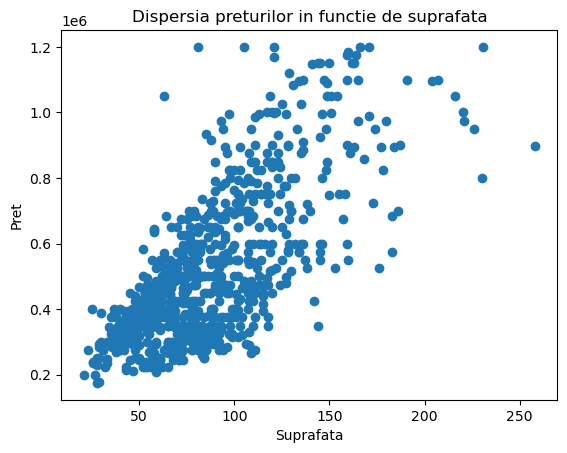

In [143]:
plt.scatter(house_df['Area'],house_df['Price'])
plt.xlabel('Suprafata')
plt.ylabel('Pret')
plt.title('Dispersia preturilor in functie de suprafata')
plt.show()

4. Analiza corelațiilor și modificarea multicoliniarității

In [144]:
# Determinăm coeficienții de corelație
house_df.corr()

,Price,Area,Room,Lon,Lat
Price,1.000000,0.717062,0.478011,-0.031655,0.108006
Area,0.717062,1.000000,0.741653,0.018257,-0.032262
Room,0.478011,0.741653,1.000000,-0.039221,-0.053695
Lon,-0.031655,0.018257,-0.039221,1.000000,-0.211604
Lat,0.108006,-0.032262,-0.053695,-0.211604,1.000000


In [145]:
corr_house = house_df.corr().round(2)
print(corr_house)

       Price  Area  Room   Lon   Lat
Price   1.00  0.72  0.48 -0.03  0.11
Area    0.72  1.00  0.74  0.02 -0.03
Room    0.48  0.74  1.00 -0.04 -0.05
Lon    -0.03  0.02 -0.04  1.00 -0.21
Lat     0.11 -0.03 -0.05 -0.21  1.00


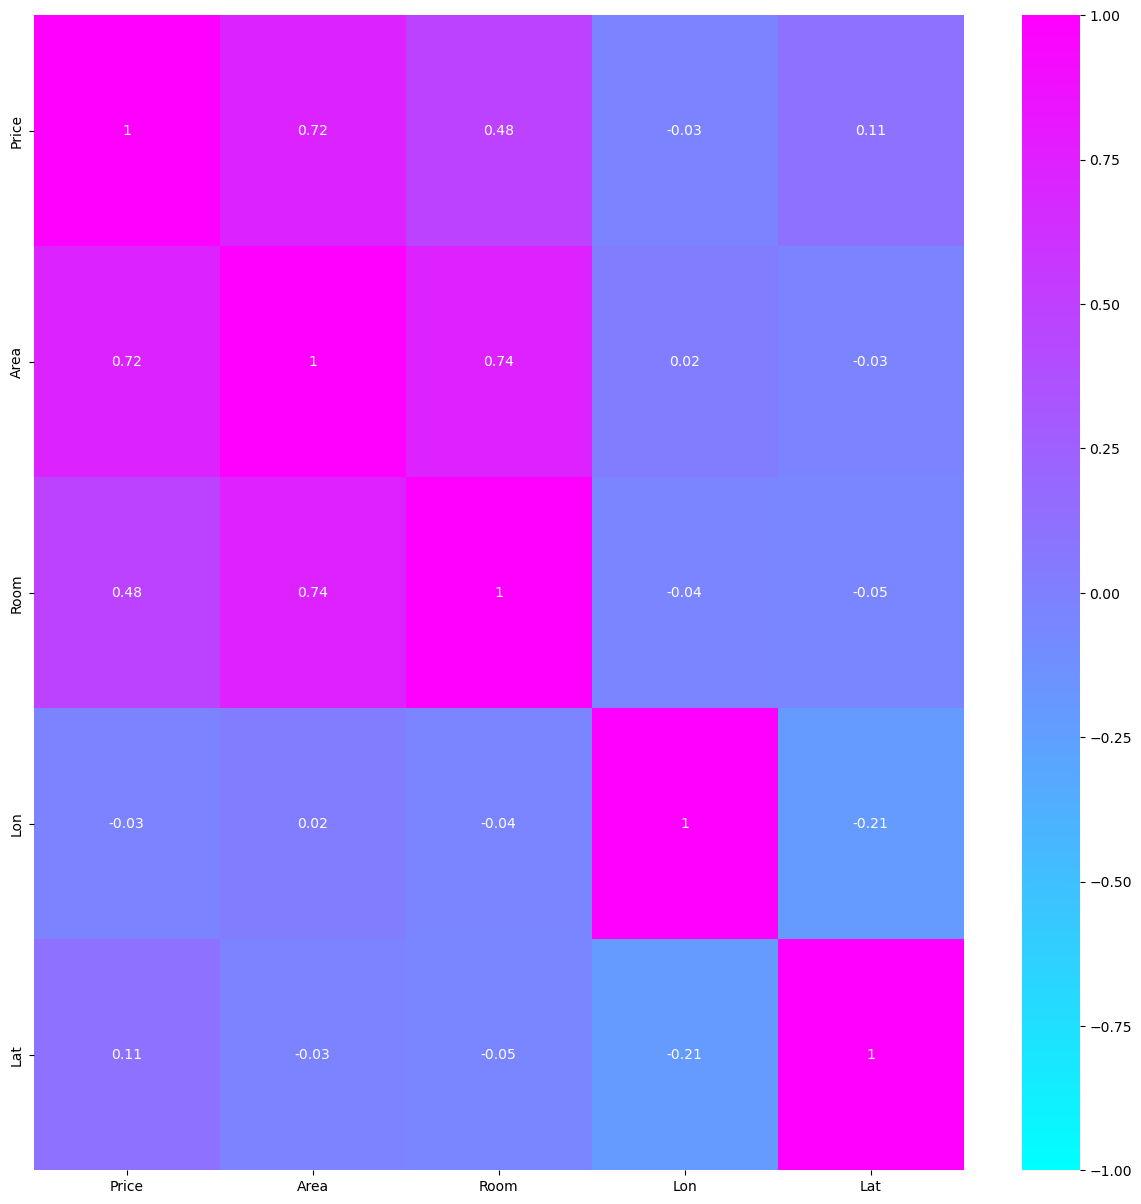

In [146]:
# Hartă de corelare
# Crearea figurii cu dimensiunea 15x15 inch
plt.figure(figsize=(15,15))

# Crearea unui heatmap pentru matricea de corelații 'corr_boston'
sns.heatmap(
    data=corr_house,   # datele care vor fi afișate în heatmap
    vmin=-1,            # valoarea minimă a culorilor (pentru scală)
    vmax=1,             # valoarea maximă a culorilor (pentru scală)
    center=0,           # centrul culorilor la 0 (pozitive vs negative)
    annot=True,         # afișează valorile numerice în celule
    cmap='cool'         # paleta de culori folosită
)

# Afișarea graficului
plt.show()

In [147]:
#Stergem si coloanele irelevante
house_df = house_df.drop(['Room'], axis=1)

In [148]:
# Verificăm că s-a efectuat corect eliminarea
print("===== Date curate ===== ") 
house_df.isna().sum()


===== Date curate ===== 


Price    0
Area     0
Lon      0
Lat      0
dtype: int64

Am observat din matricea de corelatie ca Room si Area erau puternic corelate,asa ca am ales sa sterg coloana Room.

Ce variabile prezintă corelații puternice?

Din matricea de corelație se observă că cele mai puternice legături apar între variabilele Price, Area și Room.
Cea mai mare corelație este între Area și Room (coeficient ≈ 0.74), ceea ce indică o relație puternic pozitivă — locuințele mai mari au, în mod logic, și mai multe camere.
De asemenea, se observă o corelație ridicată între Price și Area (≈ 0.72), ceea ce arată că prețul crește odată cu suprafața locuinței.
Corelația dintre Price și Room (≈ 0.48) este moderată, semn că numărul de camere influențează prețul, dar nu la fel de puternic ca suprafața.

Restul variabilelor (Lon și Lat) au corelații foarte slabe (aproape de 0), ceea ce indică faptul că poziția geografică exactă nu are o legătură liniară clară cu prețul în acest set de date.


Ce variabile au fost eliminate și de ce?

Variabila Room (numărul de camere) a fost eliminată, deoarece prezenta o corelație foarte puternică cu Area (0.74).
Această relație ridicată poate duce la multicoliniaritate — o situație în care două variabile transmit informații aproape identice, afectând performanța și interpretarea modelelor statistice sau de regresie.

Prin eliminarea lui Room, se reduce redundanța informațională, iar modelul final devine mai simplu, mai stabil și mai precis. Suprafața (Area) a fost păstrată, deoarece este o măsură mai continuă și mai relevantă pentru estimarea prețului decât numărul de camere, care este o variabilă discretă.

5.Modelul de regresie liniară – evaluare și interpretare

In [149]:
# Variabila țintă (valoarea locuinței)
y = house_df['Price']
y.head()

0    685000.0
1    475000.0
2    850000.0
3    580000.0
4    720000.0
Name: Price, dtype: float64

In [150]:
X = house_df.drop("Price", axis=1)
X.head()

,Area,Lon,Lat
0,64,4.907736,52.356157
1,60,4.850476,52.348586
2,109,4.944774,52.343782
3,128,4.789928,52.343712
4,138,4.902503,52.410538


In [151]:
# Creare date de antrenare și de testare
# Împărțirea datelor în set de antrenare și testare
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Dimensiune set antrenare:", X_train.shape, y_train.shape)
print("Dimensiune set test:", X_test.shape, y_test.shape)

Dimensiune set antrenare: (679, 3) (679,)
Dimensiune set test: (170, 3) (170,)


In [152]:
# Crearea modelului
model = LinearRegression()
# Antrenarea modelului pe datele de antrenare
model.fit(X_train, y_train)

LinearRegression()

In [153]:
print("Coeficienți:", model.coef_) #coeficienții variabilelor 
print("Intercept:", model.intercept_) #termenul liber din ecuația de regresie.

Coeficienți: [   4507.92864186    1694.20899478 1036259.410403  ]
Intercept: -54149658.34782675


In [154]:
# Prezicerea valorilor pentru setul de test
price_pred3 = model.predict(X_test)
r2_3=model.score(X_test, y_test)
print('R-square: %.4f' % r2_3 )

R-square: 0.5507


In [155]:
# Evaluarea performanței modelului

MSE3 = mean_squared_error( y_test, price_pred3)
print("MSE:", MSE3)

RMSE3 = np.sqrt(MSE3)
print("RMSE:", RMSE3)

MSE: 20762237750.708454
RMSE: 144091.07450049935


Modelul de regresie liniară, construit folosind toate variabilele din setul de date, a obținut un coeficient de determinare R2=0.5507 . Aceasta înseamnă că aproximativ 55% din variația prețului mediu al locuințelor poate fi explicată de variabilele incluse în model. Valoarea MSE este de 20.762.237.750,71, iar RMSE este de 144.091,07, ceea ce indică că predicțiile modelului se abat în medie cu aproximativ 144.000 de unități monetare față de valorile reale. Rezultatele sugerează că modelul captează o parte semnificativă din variabilitatea prețurilor locuințelor, însă există încă o marjă considerabilă de eroare în estimări.

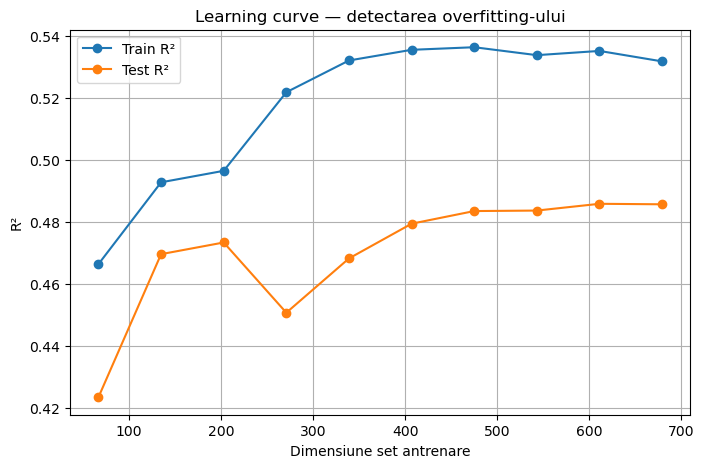

In [156]:
from sklearn.pipeline import make_pipeline

# Copiem datele și împărțim în set train/test
X_m = X.copy()      # copiați caracteristicile
y_m = y             # ținta
X_train, X_test, y_train, y_test = train_test_split(
    X_m, y_m, test_size=0.2, random_state=42
)  # 80% train, 20% test


pipeline = make_pipeline(StandardScaler(), LinearRegression())


# --- Generarea Curbei de Învățare cu Pipeline-ul ---
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, # Utilizăm Pipeline-ul
    X_m, y_m, 
    cv=5, 
    scoring='r2',  
    train_sizes=np.linspace(0.1, 1.0, 10),)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, train_mean, 'o-', label='Train R²')
plt.plot(train_sizes, test_mean, 'o-', label='Test R²')
plt.title('Learning curve — detectarea overfitting-ului')
plt.xlabel('Dimensiune set antrenare')
plt.ylabel('R²')
plt.legend()
plt.grid(True)
plt.show()

Graficul arată un overfitting, deoarece scorul R² pe antrenare este constant mai mare decât pe testare, însă diferența este mică, ceea ce indică un model relativ stabil. Performanța generală este moderată, cu R² în jur de 0.48–0.53, ceea ce înseamnă că modelul explică aproximativ jumătate din variația variabilei țintă. Pe măsură ce crește dimensiunea setului de antrenare, performanța pe testare se îmbunătățește, semn că modelul ar beneficia de și mai multe date. Variabilele cu impact semnificativ se identifică prin coeficienții modelului sau prin analiza importanței variabilelor (în funcție de algoritm), iar acestea indică direcția și intensitatea cu care fiecare caracteristică influențează predicția.

6.Regularizare Ridge si Lasso

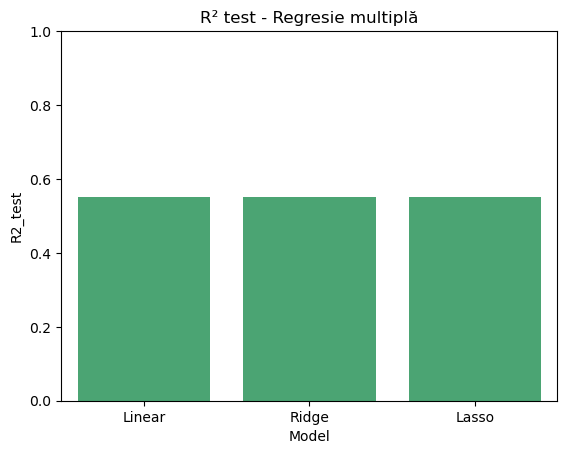

,Model,R2_test,MSE_test
0,Linear,0.550679,2.076224e+10
1,Ridge,0.550547,2.076834e+10
2,Lasso,0.550679,2.076224e+10


In [157]:
#  Regularizare Ridge, Lasso

# Standardizare date
scaler = StandardScaler()  
X_train_s = scaler.fit_transform(X_train)  # calculăm media și deviația standard pe train și transformăm
X_test_s = scaler.transform(X_test)        # transformăm test folosind media și std din train


# Antrenăm modelele
lin_multi = LinearRegression().fit(X_train_s, y_train)             # regresie liniară simplă
ridge_multi = Ridge(alpha=1.0).fit(X_train_s, y_train)            # Ridge cu alpha=1.0
lasso_multi = Lasso(alpha=0.1, max_iter=10000).fit(X_train_s, y_train)  # Lasso cu alpha=0.1 și max_iter mare pentru convergență


# Creăm o listă cu modelele și numele lor pentru iterații mai ușoare
models_multi = [('Linear', lin_multi), ('Ridge', ridge_multi), ('Lasso', lasso_multi)]


# Calculăm R² și MSE pe setul de test pentru fiecare model
r2_multi = [r2_score(y_test, m[1].predict(X_test_s)) for m in models_multi]          # R² test
mse_multi = [mean_squared_error(y_test, m[1].predict(X_test_s)) for m in models_multi]  # MSE test


# Creăm DataFrame pentru vizualizarea rezultatelor
df_r2_multi = pd.DataFrame({
    'Model': [m[0] for m in models_multi],  # numele modelelor
    'R2_test': r2_multi,                    # R² test
    'MSE_test': mse_multi                    # MSE test
})


# Vizualizăm R² pentru fiecare model
sns.barplot(data=df_r2_multi, x='Model', y='R2_test', color='mediumseagreen')  # barplot R²
plt.title('R² test - Regresie multiplă')  # titlu
plt.ylim(0,1)                              # limităm axa Y între 0 și 1
plt.show()
df_r2_multi

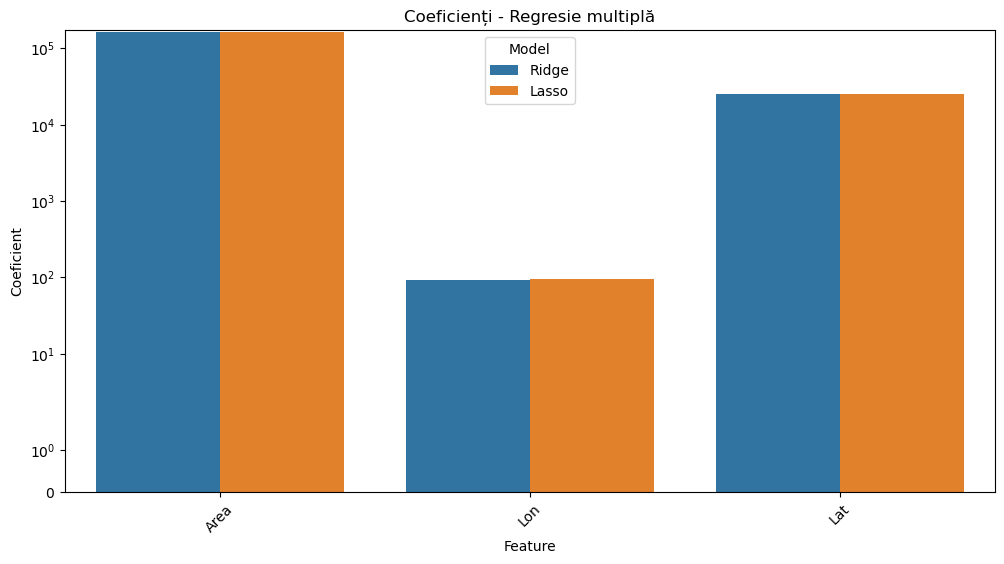

In [158]:
# Coeficienți barplot

# Creăm un DataFrame pentru coeficienți
# 'Feature' = numele caracteristicilor
# Coloanele Ridge, Lasso, ElasticNet = coeficienții fiecărui model
coef_df_multi = pd.DataFrame({
    'Feature': X.columns,          # numele caracteristicilor
    'Ridge': ridge_multi.coef_,    # coeficienți Ridge
    'Lasso': lasso_multi.coef_,    # coeficienți Lasso
     
}).melt(
    id_vars='Feature',             # păstrăm coloana Feature ca identificator
    var_name='Model',              # numele modelului devine o coloană
    value_name='Coeficient'        # valorile coeficienților devin o coloană
)


# Vizualizare coeficienți
plt.figure(figsize=(12,6))        # setăm dimensiunea figurii
sns.barplot(
    data=coef_df_multi,
    x='Feature',                  # axa X = caracteristicile
    y='Coeficient',               # axa Y = valoarea coeficientului
    hue='Model'                   # culori diferite pentru fiecare model
)
plt.yscale('symlog')
plt.title('Coeficienți - Regresie multiplă')  # titlu grafic
plt.xticks(rotation=45)                        # rotim etichetele caracteristicilor pentru claritate
plt.show()


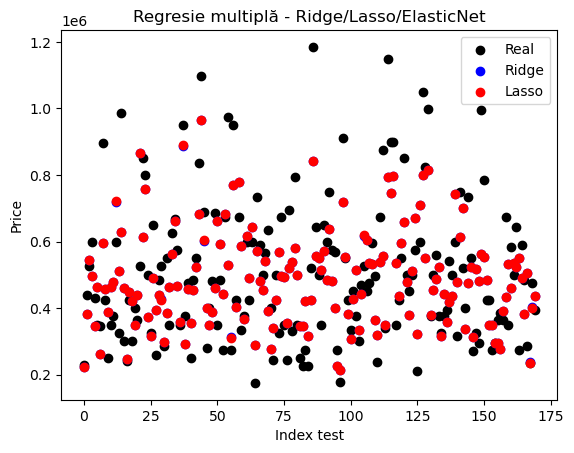

In [159]:
# Grafic predicții vs valori reale pentru regresie multiplă

# Puncte negre = valorile reale ale țintei (Price)
plt.scatter(range(len(y_test)), y_test, color='black', label='Real')

# Puncte albastre = predicțiile modelului Ridge
plt.scatter(range(len(y_test)), ridge_multi.predict(X_test_s), color='blue', label='Ridge')

# Puncte roșii = predicțiile modelului Lasso
plt.scatter(range(len(y_test)), lasso_multi.predict(X_test_s), color='red', label='Lasso')



# Eticheta axei X = indexul observațiilor din setul de test
plt.xlabel('Index test')

# Eticheta axei Y = valoarea reală a țintei (MEDV)
plt.ylabel('Price')

# Titlul graficului
plt.title('Regresie multiplă - Ridge/Lasso/ElasticNet')

# Afișăm legenda pentru a identifica fiecare model
plt.legend()

# Afișăm graficul
plt.show()

Regularizarea a avut ca efect reducerea valorilor coeficienților, făcând modelul mai puțin sensibil la variațiile din date și prevenind suprainvățarea; atât Ridge, cât și Lasso au micșorat coeficienții, însă Ridge i-a redus mai uniform, în timp ce Lasso i-a "tras" mai puternic spre zero, deși în acest caz nu a eliminat complet nicio variabilă. Prin comparație, Ridge a oferit cea mai bună stabilitate, deoarece menține toți coeficienții în model, dar le limitează amplitudinea într-un mod echilibrat, ceea ce duce la un model mai robust și cu variații mai mici ale performanței față de regresia liniară standard și față de Lasso.

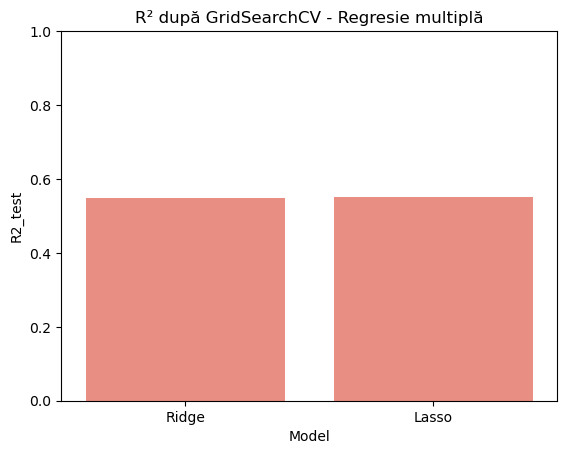

,Model,R2_test
0,Ridge,0.549453
1,Lasso,0.550626


In [160]:
# GridSearchCV pentru Ridge/Lasso

# Definim grile de valori pentru hiperparametrii
param_grid_alpha = {'alpha': np.logspace(-3, 2, 20)}               # alpha pentru Ridge și Lasso


# Cross-validation cu 5 fold-uri
cv = KFold(n_splits=5, shuffle=True, random_state=42)              # împărțire aleatorie pentru evaluare stabilă

# Definim GridSearchCV pentru fiecare model
ridge_gs = GridSearchCV(Ridge(), param_grid_alpha, cv=cv, scoring='r2', n_jobs=-1)      # Ridge
lasso_gs = GridSearchCV(Lasso(max_iter=10000), param_grid_alpha, cv=cv, scoring='r2', n_jobs=-1)  # Lasso

# Antrenăm GridSearch pentru fiecare model pe setul standardizat de train
ridge_gs.fit(X_train_s, y_train)
lasso_gs.fit(X_train_s, y_train)


# Extragem cel mai bun estimator (parametri optimi) pentru fiecare model
best_ridge = ridge_gs.best_estimator_
best_lasso = lasso_gs.best_estimator_


# Calculăm R² pe setul de test folosind cei mai buni parametri
r2_grid_multi = [
    r2_score(y_test, best_ridge.predict(X_test_s)),
    r2_score(y_test, best_lasso.predict(X_test_s)),
    
]

# Creăm DataFrame pentru vizualizare R² după GridSearchCV
df_r2_grid_multi = pd.DataFrame({
    'Model':['Ridge','Lasso'], 
    'R2_test': r2_grid_multi
})

# Vizualizăm R² pentru fiecare model după GridSearch
sns.barplot(data=df_r2_grid_multi, x='Model', y='R2_test', color='salmon')
plt.title('R² după GridSearchCV - Regresie multiplă')  # titlu grafic
plt.ylim(0,1)                                           # limităm axa Y între 0 și 1
plt.show()
df_r2_grid_multi

7. Optimizarea hiperparametrilor si concluzii finale

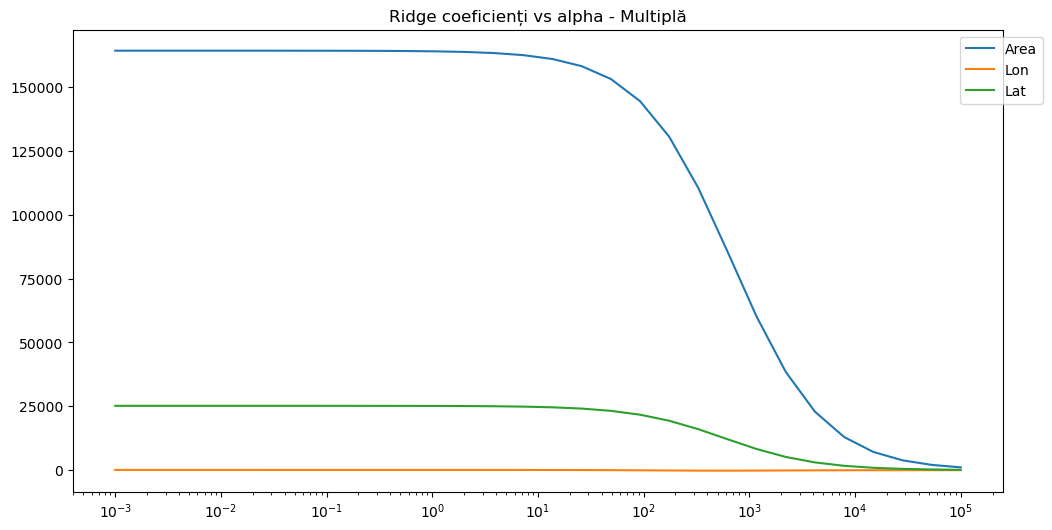

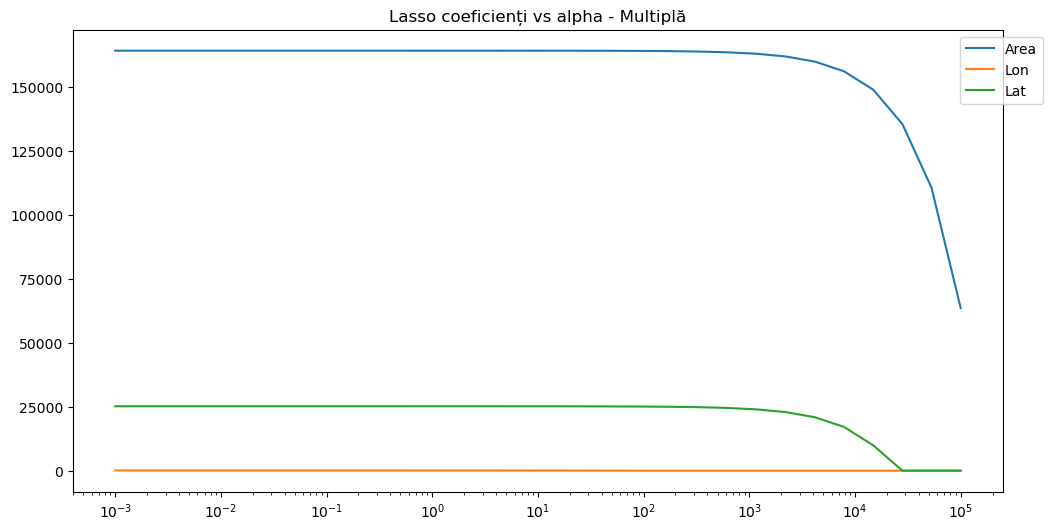

Ridge coef alpha=0.1 (multiplă): [1.64149252e+05 9.39724022e+01 2.51740147e+04]
Lasso coef alpha=0.1 (multiplă): [1.64169878e+05 9.40588373e+01 2.51776170e+04]


In [161]:
# Coeficienți vs alpha (multiplă)

# Definim un set de valori alpha pentru penalizare
alphas = np.logspace(-3,5,30)  # valori între 0.001 și 100

# Liste pentru coeficienți la fiecare alpha
ridge_coefs_multi, lasso_coefs_multi = [], []


# Iterăm peste toate valorile de alpha
for a in alphas:
    # Antrenăm Ridge pentru alpha curent și salvăm coeficienții
    ridge_coefs_multi.append(Ridge(alpha=a).fit(X_train_s, y_train).coef_)
    
    # Antrenăm Lasso pentru alpha curent și salvăm coeficienții
    lasso_coefs_multi.append(Lasso(alpha=a, max_iter=10000).fit(X_train_s, y_train).coef_)
    
   
# Transformăm listele în array-uri NumPy pentru manipulare ușoară
ridge_coefs_multi = np.array(ridge_coefs_multi)
lasso_coefs_multi = np.array(lasso_coefs_multi)


# Grafic Ridge coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X.columns):
    plt.plot(alphas, ridge_coefs_multi[:,i], label=feat)  # fiecare linie = un feature
plt.xscale('log')  # axa X pe scară logaritmică pentru alpha
plt.title('Ridge coeficienți vs alpha - Multiplă')
plt.legend(bbox_to_anchor=(1.05,1))  # legenda în afara graficului
plt.show()


# Grafic Lasso coeficienți vs alpha
plt.figure(figsize=(12,6))
for i, feat in enumerate(X.columns):
    plt.plot(alphas, lasso_coefs_multi[:,i], label=feat)
plt.xscale('log')
plt.title('Lasso coeficienți vs alpha - Multiplă')
plt.legend(bbox_to_anchor=(1.05,1))
plt.show()




# Print coeficienți pentru alpha=0.1
idx = np.argmin(abs(alphas-0.1))  # găsim indexul celei mai apropiate valori alpha=0.1
print("Ridge coef alpha=0.1 (multiplă):", ridge_coefs_multi[idx])
print("Lasso coef alpha=0.1 (multiplă):", lasso_coefs_multi[idx])



În această analiză, hiperparametrul selectat a fost α = 0.1 pentru modelele Ridge și Lasso, valoare la care coeficienții au rămas stabili și modelul a obținut rezultate similare sau ușor îmbunătățite față de regresia liniară simplă, reducând riscul de overfitting; performanța s-a îmbunătățit prin faptul că regularizarea a redus amplitudinea coeficienților și a crescut robustețea modelului, menținând un R² similar dar cu o stabilitate mai bună a predicțiilor. Concluzia generală este că regularizarea a ajutat modelul să fie mai echilibrat, evitând supraantrenarea și controlând influența variabilelor, iar Ridge s-a dovedit a fi cea mai stabilă metodă dintre cele aplicate.